In [2]:
!pip install torch torchvision datasets scikit-image pillow -q

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image, ImageEnhance
import numpy as np
from skimage.color import rgb2lab, lab2rgb
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# ───────────────────────────────────────────────────────────
# Building Blocks
# ───────────────────────────────────────────────────────────

class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ch),
        )
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(x + self.block(x))


class CBAM(nn.Module):
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc  = nn.Sequential(
            nn.Linear(ch, ch // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(ch // reduction, ch, bias=False),
        )
        self.spatial = nn.Conv2d(2, 1, 7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.shape
        avg = self.fc(self.avg(x).view(b, c)).view(b, c, 1, 1)
        mx  = self.fc(self.max(x).view(b, c)).view(b, c, 1, 1)
        x   = x * self.sigmoid(avg + mx)
        avg_s = x.mean(dim=1, keepdim=True)
        max_s = x.max(dim=1, keepdim=True)[0]
        x = x * self.sigmoid(self.spatial(torch.cat([avg_s, max_s], dim=1)))
        return x


def _match_size(x, ref):
    """Fix any spatial mismatch between decoder and skip connection."""
    if x.shape[2:] != ref.shape[2:]:
        x = F.interpolate(x, size=ref.shape[2:], mode="bilinear", align_corners=True)
    return x


# ───────────────────────────────────────────────────────────
# ColorizationNet — U-Net + ResBlocks + CBAM Attention
# ───────────────────────────────────────────────────────────

class ColorizationNet(nn.Module):
    """
    Input : L channel (1, H, W) normalised to [-1, 1]
    Output: ab channels (2, H, W) in [-1, 1]
    Works at ANY resolution — skip mismatches fixed via _match_size.
    """
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(ConvBnRelu(1,   64),                  ResBlock(64))
        self.enc2 = nn.Sequential(ConvBnRelu(64,  128, stride=2),        ResBlock(128))
        self.enc3 = nn.Sequential(ConvBnRelu(128, 256, stride=2),        ResBlock(256))
        self.enc4 = nn.Sequential(ConvBnRelu(256, 512, stride=2),        ResBlock(512))
        self.att4 = CBAM(512)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            ConvBnRelu(512, 512, stride=2),
            ResBlock(512), ResBlock(512),
            ConvBnRelu(512, 512),
        )

        # Decoder — bilinear upsample (no transposed conv checkerboard)
        self.up4   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv4 = nn.Sequential(ConvBnRelu(512,        512), ResBlock(512))

        self.up3   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv3 = nn.Sequential(ConvBnRelu(512 + 512,  256), ResBlock(256))

        self.up2   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv2 = nn.Sequential(ConvBnRelu(256 + 256,  128), ResBlock(128))

        self.up1   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv1 = nn.Sequential(ConvBnRelu(128 + 128,   64), ResBlock(64))

        self.up0   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv0 = ConvBnRelu(64 + 64, 64)

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 2, 1),
            nn.Tanh(),
        )

    def forward(self, L):
        e1 = self.enc1(L)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e4 = self.att4(e4)

        b  = self.bottleneck(e4)

        d4 = self.conv4(self.up4(b))
        d4 = _match_size(d4, e4)

        d3 = self.conv3(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d3)
        d3 = _match_size(d3, e3)

        d2 = self.conv2(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d2)
        d2 = _match_size(d2, e2)

        d1 = self.conv1(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d1)
        d1 = _match_size(d1, e1)

        d0 = self.conv0(torch.cat([d1, e1], dim=1))
        d0 = self.up0(d0)
        d0 = _match_size(d0, L)   # final safety net

        return self.head(d0)


# ───────────────────────────────────────────────────────────
# Loss
# ───────────────────────────────────────────────────────────

class ColorizationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.SmoothL1Loss()

    def forward(self, pred_ab, true_ab):
        pixel_loss  = self.l1(pred_ab, true_ab)
        # Penalise grey outputs — forces richer color predictions
        sat_penalty = F.relu(0.15 - pred_ab.abs().mean())
        return pixel_loss + 0.05 * sat_penalty


# ───────────────────────────────────────────────────────────
# Dataset
# ───────────────────────────────────────────────────────────

class ColorizationDataset(Dataset):
    def __init__(self, hf_dataset, size=256):
        self.data   = hf_dataset
        self.size   = size
        self.resize = transforms.Resize(
            (size, size), interpolation=transforms.InterpolationMode.BICUBIC
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]["image"]
        if img is None:
            img = Image.new("RGB", (self.size, self.size))
        img = img.convert("RGB")
        img = self.resize(img)

        img_np = np.array(img, dtype=np.float32) / 255.0
        lab    = rgb2lab(img_np).astype(np.float32)

        L  = lab[:, :, 0] / 50.0 - 1.0            # → [-1, 1]
        ab = lab[:, :, 1:] / 110.0                 # → ~[-1, 1]

        L  = torch.from_numpy(L).unsqueeze(0)       # (1, H, W)
        ab = torch.from_numpy(ab).permute(2, 0, 1)  # (2, H, W)
        return L, ab


def get_dataloaders(dataset_name="nelorth/oxford-flowers",
                    batch_size=16, img_size=256, num_workers=2):
    print(f"Loading dataset: {dataset_name} ...")
    raw    = load_dataset(dataset_name)
    splits = list(raw.keys())

    train_split = next((s for s in ["train", "training"]           if s in splits), splits[0])
    val_split   = next((s for s in ["validation", "test", "valid"] if s in splits),
                       splits[1] if len(splits) > 1 else splits[0])

    print(f"  Train : '{train_split}' — {len(raw[train_split])} samples")
    print(f"  Val   : '{val_split}'  — {len(raw[val_split])} samples")

    train_ds = ColorizationDataset(raw[train_split], img_size)
    val_ds   = ColorizationDataset(raw[val_split],   img_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    return train_loader, val_loader


# ───────────────────────────────────────────────────────────
# Training
# ───────────────────────────────────────────────────────────

def train_model(
    dataset_name = "nelorth/oxford-flowers",
    epochs       = 30,
    batch_size   = 8,        # safe for Colab T4 (12 GB)
    img_size     = 256,
    lr           = 2e-4,
    save_path    = "colorization_model.pth",
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device : {device}")

    train_loader, val_loader = get_dataloaders(
        dataset_name=dataset_name,
        batch_size=batch_size,
        img_size=img_size,
    )

    model     = ColorizationNet().to(device)
    criterion = ColorizationLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        # — Train —
        model.train()
        train_loss = 0.0
        for L, ab in train_loader:
            L, ab = L.to(device), ab.to(device)
            optimizer.zero_grad()
            pred_ab = model(L)
            loss = criterion(pred_ab, ab)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        # — Validate —
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for L, ab in val_loader:
                L, ab = L.to(device), ab.to(device)
                val_loss += criterion(model(L), ab).item()

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        scheduler.step()

        print(f"Epoch {epoch:3d}/{epochs}  |  train={train_loss:.4f}  val={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  ✔ Saved → {save_path}")

    print("\nTraining complete. Best val loss:", round(best_val, 4))
    return model


# ───────────────────────────────────────────────────────────
# Post-processing & Inference
# ───────────────────────────────────────────────────────────

def post_process_lab(L_np, ab_np, saturation_boost=1.35):
    """Convert L + predicted ab back to RGB with optional saturation boost."""
    L_denorm  = (L_np  + 1.0) * 50.0
    ab_denorm = ab_np  * 110.0 * saturation_boost

    lab = np.concatenate([L_denorm[..., None], ab_denorm], axis=-1).astype(np.float64)
    lab[..., 0] = np.clip(lab[..., 0],   0, 100)
    lab[..., 1] = np.clip(lab[..., 1], -128, 127)
    lab[..., 2] = np.clip(lab[..., 2], -128, 127)

    return (np.clip(lab2rgb(lab), 0, 1) * 255).astype(np.uint8)


def colorize(
    image_source,              # file path (str) or PIL.Image
    model_path  = "colorization_model.pth",
    img_size    = 256,
    saturation  = 1.35,        # increase to 1.6–1.8 for more vivid colors
    sharpness   = 1.4,         # post-process sharpening
    output_path = None,        # set to a filename to save, e.g. "out.jpg"
):
    """
    Colorize a B&W image. Returns a PIL Image.
    Works with file paths or PIL Images directly.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model
    model = ColorizationNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Load image
    if isinstance(image_source, str):
        img = Image.open(image_source).convert("RGB")
    else:
        img = image_source.convert("RGB")

    orig_w, orig_h = img.size
    img_r  = img.resize((img_size, img_size), Image.BICUBIC)
    img_np = np.array(img_r, dtype=np.float32) / 255.0
    lab    = rgb2lab(img_np).astype(np.float32)
    L      = lab[:, :, 0] / 50.0 - 1.0

    L_t = torch.from_numpy(L).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        ab_pred = model(L_t)

    ab_np = ab_pred.squeeze(0).permute(1, 2, 0).cpu().numpy()
    L_np  = L_t.squeeze().cpu().numpy()

    # Reconstruct & enhance
    colorized = post_process_lab(L_np, ab_np, saturation_boost=saturation)
    result    = Image.fromarray(colorized).resize((orig_w, orig_h), Image.LANCZOS)
    result    = ImageEnhance.Sharpness(result).enhance(sharpness)
    result    = ImageEnhance.Contrast(result).enhance(1.05)

    if output_path:
        result.save(output_path, quality=97)
        print(f"Saved → {output_path}")

    return result

print("✅ All classes and functions loaded successfully.")

✅ All classes and functions loaded successfully.


In [4]:
model = train_model(
    dataset_name = "nelorth/oxford-flowers",
    epochs       = 30,
    batch_size   = 8,    # lower to 4 if you get CUDA OOM
    img_size     = 256,
    lr           = 2e-4,
    save_path    = "colorization_model.pth",
)

Device : cuda
Loading dataset: nelorth/oxford-flowers ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-12de94e121bdbe(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

data/test-00000-of-00001-96eeec628415add(…):   0%|          | 0.00/43.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1020 [00:00<?, ? examples/s]

  Train : 'train' — 7169 samples
  Val   : 'test'  — 1020 samples
Epoch   1/30  |  train=0.0219  val=0.0237
  ✔ Saved → colorization_model.pth
Epoch   2/30  |  train=0.0206  val=0.0200
  ✔ Saved → colorization_model.pth
Epoch   3/30  |  train=0.0200  val=0.0197
  ✔ Saved → colorization_model.pth
Epoch   4/30  |  train=0.0196  val=0.0198
Epoch   5/30  |  train=0.0192  val=0.0188
  ✔ Saved → colorization_model.pth
Epoch   6/30  |  train=0.0188  val=0.0192
Epoch   7/30  |  train=0.0183  val=0.0188
  ✔ Saved → colorization_model.pth
Epoch   8/30  |  train=0.0180  val=0.0181
  ✔ Saved → colorization_model.pth
Epoch   9/30  |  train=0.0175  val=0.0179
  ✔ Saved → colorization_model.pth
Epoch  10/30  |  train=0.0169  val=0.0183
Epoch  11/30  |  train=0.0162  val=0.0178
  ✔ Saved → colorization_model.pth
Epoch  12/30  |  train=0.0153  val=0.0174
  ✔ Saved → colorization_model.pth
Epoch  13/30  |  train=0.0144  val=0.0168
  ✔ Saved → colorization_model.pth
Epoch  14/30  |  train=0.0135  val=0.0

Found image: /kaggle/input/datasets/anikahossain222/flower/black-and-white-image.jpg
Saved → /kaggle/working/colorized_result.jpg


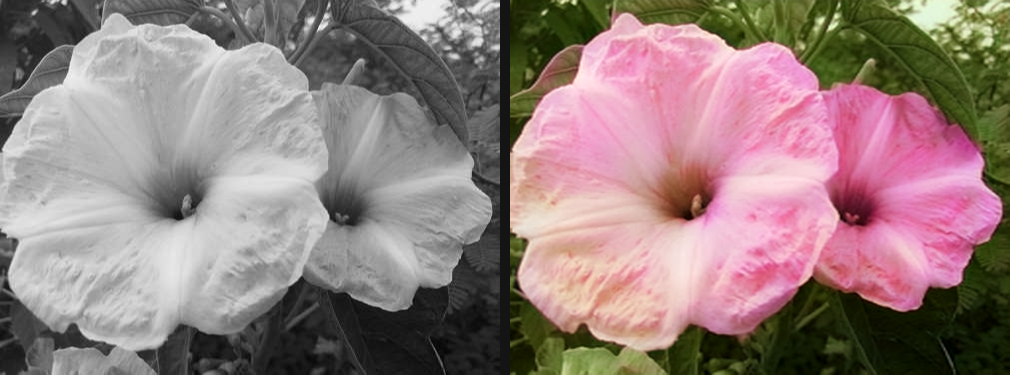

Left: B&W   |   Right: Colorized
✅ Saved to /kaggle/working/colorized_result.jpg
   Download from the Output tab on the right →


In [ ]:
import os
from PIL import Image
from IPython.display import display


INPUT_DIR = "/kaggle/input"

# Auto-find the first image file under /kaggle/input
image_path = None
for root, dirs, files in os.walk(INPUT_DIR):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            image_path = os.path.join(root, f)
            break
    if image_path:
        break

if image_path is None:
    print("⚠ No image found. Add one via: Add Input → Upload (right sidebar)")
else:
    print(f"Found image: {image_path}")

    result = colorize(
        image_source = image_path,
        model_path   = "colorization_model.pth",
        img_size     = 256,
        saturation   = 1.35,
        sharpness    = 1.4,
        output_path  = "/kaggle/working/colorized_result.jpg",
    )

    
    original = Image.open(image_path).convert("L").convert("RGB")
    orig_w, orig_h = original.size
    comparison = Image.new("RGB", (orig_w * 2 + 10, orig_h), (20, 20, 20))
    comparison.paste(original, (0, 0))
    comparison.paste(result,   (orig_w + 10, 0))

    display(comparison)
    print("Left: B&W   |   Right: Colorized")
    print("✅ Saved to /kaggle/working/colorized_result.jpg")
    print("   Download from the Output tab on the right →")